Code to train model for gesture classification. A similar classification model was developed in [sEMG-Forearm-Classification](github.com/LilOz/sEMG-Forearm-Classification) and was referenced during development of this model.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CONFIG VARIABLES
window_length = 0.128   # length of window (seconds)
window_overlap = 0.75   # overlap between window (value between 0 and 1)
fs = 250                # sampling frequency (Hz)
n_hidden_neurons = 50   # number of neurons in hidden layers
n_classes = 6           # number of classes (gestures that can be classified)
learning_rate = 0.001   # learning rate


# GESTURES
poses ={1 : "Rest",
        2 : "Fist",
        3 : "Flexion",
        4 : "Extension",
        5 :" Radial",
        6 : "Ulnar"}

Read in data from labelled text files. Training data will be collected and labelled using [EMGPromptApp](github.com/LilOz/EMGPromptApp), a tool developed by Ayman Osman.

Training data generated by EMGPromptApp is placed in folders. Create a zip of all the training data and upload it to this notebook, update the folder name as seen below

```
!unzip [YOUR_FOLDER_HERE]
current_dir = Path([YOUR_FOLDER_HERE])
```



In [ ]:
!unzip CytonData.zip
%ls

Archive:  CytonData.zip
   creating: CytonData/
   creating: CytonData/left3_2026-05-26_23-05-21/
  inflating: CytonData/left3_2026-05-26_23-05-21/labeled_emg_output.txt  
  inflating: CytonData/left3_2026-05-26_23-05-21/labels.csv  
  inflating: CytonData/left3_2026-05-26_23-05-21/OpenBCI-RAW-2026-05-26_22-57-00.txt  
   creating: CytonData/left4_2026-05-26_23-14-48/
  inflating: CytonData/left4_2026-05-26_23-14-48/labeled_emg_output.txt  
  inflating: CytonData/left4_2026-05-26_23-14-48/labels.csv  
  inflating: CytonData/left4_2026-05-26_23-14-48/OpenBCI-RAW-2026-05-26_23-14-41.txt  
   creating: CytonData/left5_2026-05-26_23-22-34/
  inflating: CytonData/left5_2026-05-26_23-22-34/labeled_emg_output.txt  
  inflating: CytonData/left5_2026-05-26_23-22-34/labels.csv  
  inflating: CytonData/left5_2026-05-26_23-22-34/OpenBCI-RAW-2026-05-26_23-22-27.txt  
   creating: CytonData/right3_2026-05-26_23-10-33/
  inflating: CytonData/right3_2026-05-26_23-10-33/labeled_emg_output.txt  
  infla

In [ ]:
from pathlib import Path
from sklearn.preprocessing import StandardScaler

current_dir = Path('CytonData')

channel_cols =  [' EXG Channel 0', ' EXG Channel 1', ' EXG Channel 2', ' EXG Channel 3',
                 ' EXG Channel 4', ' EXG Channel 5', ' EXG Channel 6', ' EXG Channel 7']
class_col =     ['class']

full_dataset = []

# loop through folders in current directory
for dir in current_dir.iterdir():
  if dir.is_dir():

    # looping through files in each foler
    for f in dir.iterdir():

      # finding labelled emg files
      if f.is_file() and f.name == 'labeled_emg_output.txt':
        print("found file")
        try:
          data = pd.read_csv(f, comment='%', skiprows=0, usecols=channel_cols+class_col)

          if 'right' in dir.name.lower():
              data[channel_cols] = np.flip(data[channel_cols].to_numpy(), axis=1)

          # normalise data using z transform
          scaler = StandardScaler()
          data[channel_cols] = scaler.fit_transform(data[channel_cols])

          full_dataset.append(data)

          print(f"Processed data in {dir.name}, {data['class'].size} samples")

        except Exception as e:
          print(f"Error '{e}' when processing {f}")

full_dataset = pd.concat(full_dataset, ignore_index=True)
print(f"Processing finished, {full_dataset['class'].size} total samples")

found file
Processed data in right4_2026-05-26_23-18-54, 42629 samples
found file
Processed data in right3_2026-05-26_23-10-33, 43662 samples
found file
Processed data in left5_2026-05-26_23-22-34, 41402 samples
found file
Processed data in left3_2026-05-26_23-05-21, 38975 samples
found file
Processed data in left4_2026-05-26_23-14-48, 41964 samples
found file
Processed data in right5_2026-05-26_23-26-03, 41878 samples
Processing finished, 250510 total samples


Extracting features from the sEMG data. These features have been selected based on existing research and after verifying the feasibility of computing the features in real time.

In [ ]:
from scipy.stats import skew, kurtosis

# Integrated EMG
def iemg(data):
  return np.sum(np.abs(data))

# Mean Squared Value
def msv(data):
  return np.sum(data**2) / len(data)

def variance(data):
  return np.sum((data - np.mean(data))**2) / (len(data) - 1)

# Root mean square
def rms(data):
  return np.sqrt(np.sum(data**2) / (len(data)))

# ln(RMS)
def ln_rms(data):
  return np.log(np.sqrt(np.sum(data**2) / (len(data))))

# Kurtosis (measure of sharpness in the sample distribution)
def kurt(data):
  return (np.sum(pow((data - np.mean(data))/np.std(data), 4)) / len(data)) - 3

# Skewness (measure of asymmetry of measure contractions)
def skewness(data):
  return (np.sum(pow((data - np.mean(data))/np.std(data), 3)) / len(data))

# Mean Absolute Value
def mav(data):
  return np.sum(np.abs(data)) / len(data)

# Waveform Length
def waveform_length(data):
  return np.sum([data[i+1] - data[i] for i in range(len(data))])

features = [iemg, msv, variance, rms, ln_rms, kurt, skewness]
n_features = len(features)

# Extracting features and creating feature vector
def get_feature_vector(window):
  feature_vector = []
  for i in range(8):
    channel_data = window[f' EXG Channel {i}']
    channel_features = [iemg(channel_data), msv(channel_data), variance(channel_data), rms(channel_data),
                        ln_rms(channel_data), kurt(channel_data), skewness(channel_data)]
    feature_vector += (channel_features)
  return feature_vector

Getting true feature vector from test frame for ESP32 validation

In [ ]:
features = get_feature_vector(full_dataset)
print_output = "float TrueFeatures[] = {"
for i in range(len(features)):
  print_output += f" {features[i]}f"
  if (i != len(features) - 1):
    print_output += ", "
print_output += "};"

print(print_output)

float TrueFeatures[] = { 195301.77450279117f,  0.9999999999999999f,  1.0000039918725474f,  0.9999999999999999f,  -1.1102230246251565e-16f,  0.938383596078812f,  -0.13488550794988008f,  192367.1340173096f,  0.9999999999999999f,  1.0000039918725474f,  0.9999999999999999f,  -1.1102230246251565e-16f,  1.0214077383461557f,  0.15887157355459472f,  192555.41036153046f,  0.9999999999999999f,  1.0000039918725474f,  0.9999999999999999f,  -1.1102230246251565e-16f,  0.43372729786709296f,  -0.13807036926939326f,  197593.83024404445f,  1.0f,  1.0000039918725474f,  1.0f,  0.0f,  0.6229098232975159f,  0.18118890691944767f,  197572.47963306564f,  0.9999999999999999f,  1.0000039918725474f,  0.9999999999999999f,  -1.1102230246251565e-16f,  0.3497243891491242f,  0.057973156489633595f,  198051.83611758554f,  0.9999999999999998f,  1.0000039918725472f,  0.9999999999999999f,  -1.1102230246251565e-16f,  0.10480333801647701f,  -0.03840487902537324f,  197158.03454447025f,  1.0f,  1.0000039918725474f,  1.0f,  0.0

Generating windows from data, window is labelled with class (gesture) that appears most in the window

In [ ]:
from sklearn.model_selection import train_test_split

window_size = fs * window_length
overlap_n = window_size - int(window_size * window_overlap)

def get_windows(dataset):
  labels = []
  data = []
  windows = []
  for i in range(dataset[class_col].size - int(window_size)):
    windows.append(dataset.iloc[i:i+int(window_size)])
    i += int(overlap_n)

  for w in windows:
    class_mode = w[class_col].mode().iloc[0]
    if class_mode['class'] != 0:
      labels.append(class_mode - 1)
      data.append(w[channel_cols])
  return data, labels

data, labels = get_windows(full_dataset)
print(f"Created {len(labels)} windows from the dataset")
data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.25, random_state=42)
print(f"Test and training data generated: data_train ({len(data_train)}), data_test ({len(data_test)})")

Created 118383 windows from the dataset
Test and training data generated: data_train (88787), data_test (29596)


Creating MLP model with one hidden layer

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input

model = Sequential([
    Input(shape=(56,)),
    Dense(n_hidden_neurons, activation='relu'),
    Dense(n_classes, activation='softmax'),
])

model.compile(optimizer=Adam(learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │         2,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,156 (12.33 KB)

 Trainable params: 3,156 (12.33 KB)

 Non-trainable params: 0 (0.00 B)

None


Extracting the features and training the model

In [ ]:
features_train = []
for w in data_train:
  features_train.append(get_feature_vector(w))
features_train = np.array(features_train)
labels_train = np.array(labels_train)


features_test = []
for w in data_test:
  features_test.append(get_feature_vector(w))
features_test = np.array(features_test)
labels_test = np.array(labels_test)

In [ ]:
mod = model.fit(features_train, labels_train, epochs=200,
                batch_size=2000,
                validation_split=0.33,
                shuffle=True)

print(mod)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2230 - loss: 9.8725 - val_accuracy: 0.2329 - val_loss: 5.5127
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2228 - loss: 4.1811 - val_accuracy: 0.2635 - val_loss: 3.1354
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2868 - loss: 2.6234 - val_accuracy: 0.3195 - val_loss: 2.1971
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3260 - loss: 2.0279 - val_accuracy: 0.3366 - val_loss: 1.8668
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3505 - loss: 1.7832 - val_accuracy: 0.3761 - val_loss: 1.6884
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3895 - loss: 1.6390 - val_accuracy: 0.4209 - val_loss: 1.5789
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4316 - loss: 1.5449 - val_accuracy: 0.4490 - val_loss: 1.4994
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4614 - loss: 1.4758 - val_accuracy: 0.4811 

In [ ]:
results = model.evaluate(features_test, labels_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.260399729013443, 0.925327718257904]


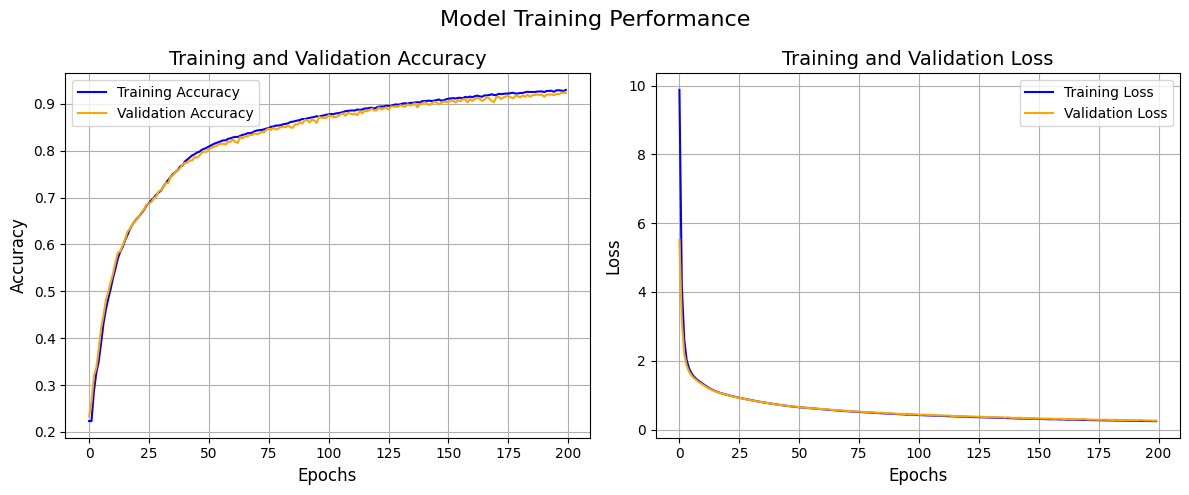

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

Printing weights in a format that can be copied and pasted into weights.h in the ESP32 firmware



In [ ]:
# getting training standard deviations and means

training_mean_string = "const float TRAIN_MEAN[] = { "
training_sd_string = "const float TRAIN_SD[] = { "

for i in range(8):
    channel_data = full_dataset[f' EXG Channel {i}']
    training_sd_string += f"{np.std(channel_data)}f"
    training_mean_string += f"{np.mean(channel_data)}f"

    if i != 7:
      training_sd_string += ", "
      training_mean_string += ", "

training_sd_string += " };"
training_mean_string += " };"

print(training_mean_string)
print(training_sd_string)

const float TRAIN_MEAN[] = { 5.445858658973264e-18f, 9.802545586151875e-17f, 1.198088904974118e-16f, 2.1783434635893056e-17f, -3.2675151953839584e-17f, 4.7197441711101624e-17f, -1.325158940350161e-16f, 1.0347131452049201e-16f };
const float TRAIN_SD[] = { 1.000000000000003f, 1.0000000000000142f, 0.9999999999999983f, 1.000000000000001f, 0.9999999999999994f, 1.0000000000000064f, 1.0000000000000155f, 1.0000000000000007f };


In [ ]:
# getting model weights

weights = model.get_weights()

hidden_weights_1 = weights[0]
hidden_bias_1 = weights[1]
# hidden_weights_2 = weights[2]
# hidden_bias_2 = weights[3]
output_weights = weights[2]
output_bias = weights[3]

n_weights = len(hidden_weights_1) + len(hidden_bias_1) + len(output_bias) + len(output_weights)
print(n_weights)

flattened_weights_string = "const float WEIGHTS[] PROGMEM = {"

# input -> first hidden layer weights
for i in range(8 * n_features):
  for j in range(n_hidden_neurons):
    flattened_weights_string += f" {hidden_weights_1[i,j]}f,"

# first hidden layer bias weights
for i in range(n_hidden_neurons):
  flattened_weights_string += f" {hidden_bias_1[i]}f,"

# # first hidden layer -> second hidden layer weights
# for i in range(n_hidden_neurons):
#   for j in range(n_hidden_neurons):
#     flattened_weights_string += f" {hidden_weights_2[i,j]}f,"

# # second hidden layer bias weights
# for i in range(n_hidden_neurons):
#   flattened_weights_string += f" {hidden_bias_2[i]}f,"

# output layer weights
for i in range(n_hidden_neurons):
  for j in range(n_classes):
    flattened_weights_string += f" {output_weights[i,j]}f,"

# output layer bias weights
for i in range(n_classes):
  flattened_weights_string += f" {output_bias[i]}f"
  if i != n_classes - 1:
    flattened_weights_string += ","


flattened_weights_string += " };"

print(flattened_weights_string)

162
const float WEIGHTS[] PROGMEM = { -0.21700873970985413f, 0.2632335424423218f, 0.1967962384223938f, -0.18326863646507263f, -0.06077113375067711f, -0.3394468128681183f, -0.08614466339349747f, 0.1436893343925476f, 0.11594860255718231f, -0.18913553655147552f, -0.37261971831321716f, -0.3824283480644226f, 0.25278231501579285f, -0.22685600817203522f, 0.2118932157754898f, -0.01416989229619503f, 0.03582775220274925f, -0.10821457952260971f, 0.30081242322921753f, -0.0803639143705368f, -0.07834858447313309f, 0.29168298840522766f, -0.20114852488040924f, 0.26662206649780273f, 0.003181382780894637f, 0.04595117270946503f, -0.43958717584609985f, 0.18385906517505646f, -0.7479498982429504f, 0.22133885324001312f, -0.060056332498788834f, -0.3094540536403656f, -0.07076358795166016f, -0.13450202345848083f, 0.04113435000181198f, -0.11558675765991211f, 0.1108863577246666f, 0.16996194422245026f, -0.04996217042207718f, -0.4486677348613739f, 0.032560694962739944f, 0.28299272060394287f, -0.30082932114601135f, 